# Exercise 09 — Karate Club Split



In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)

G = nx.karate_club_graph()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected:", nx.is_connected(G))

Nodes: 34
Edges: 78
Connected: True


## 2. Resilience metric

After each removal step we measure:

**Largest Connected Component (LCC)**

This metric represents the size of the largest remaining connected group.


In [ ]:
def largest_component_size(graph):
    if graph.number_of_nodes() == 0:
        return 0

    components = list(nx.connected_components(graph))
    return len(max(components, key=len))

## 3. Random node removal

Nodes are removed in a random order.

This simulates accidental departures, inactivity, or random failures.


In [ ]:
random_graph = G.copy()

random_nodes = list(random_graph.nodes())
random.shuffle(random_nodes)

random_results = []

for step, node in enumerate(random_nodes, start=1):
    random_graph.remove_node(node)

    random_results.append({
        "step": step,
        "removed_node": node,
        "largest_component": largest_component_size(random_graph)
    })

random_df = pd.DataFrame(random_results)

random_df.head()

,step,removed_node,largest_component
0,1,5,33
1,2,19,32
2,3,20,31
3,4,12,30
4,5,24,29


## 4. Targeted attack using degree

Nodes are removed from highest degree to lowest degree.

This simulates the removal of leaders, hubs, or highly connected members.


In [ ]:
target_graph = G.copy()

degree_order = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)

target_results = []

for step, (node, degree) in enumerate(degree_order, start=1):
    target_graph.remove_node(node)

    target_results.append({
        "step": step,
        "removed_node": node,
        "degree": degree,
        "largest_component": largest_component_size(target_graph)
    })

target_df = pd.DataFrame(target_results)

target_df.head()

,step,removed_node,degree,largest_component
0,1,33,17,33
1,2,0,16,26
2,3,32,12,20
3,4,2,10,10
4,5,1,9,8


## 5. Compare random failure and targeted attack

We compare the size of the largest connected component after each removal.


In [ ]:
comparison_df = pd.DataFrame({
    "step": random_df["step"],
    "random_failure": random_df["largest_component"],
    "targeted_attack": target_df["largest_component"]
})

comparison_df.head(10)

,step,random_failure,targeted_attack
0,1,33,33
1,2,32,26
2,3,31,20
3,4,30,10
4,5,29,8
5,6,28,8
6,7,27,6
7,8,26,6
8,9,25,6
9,10,24,5


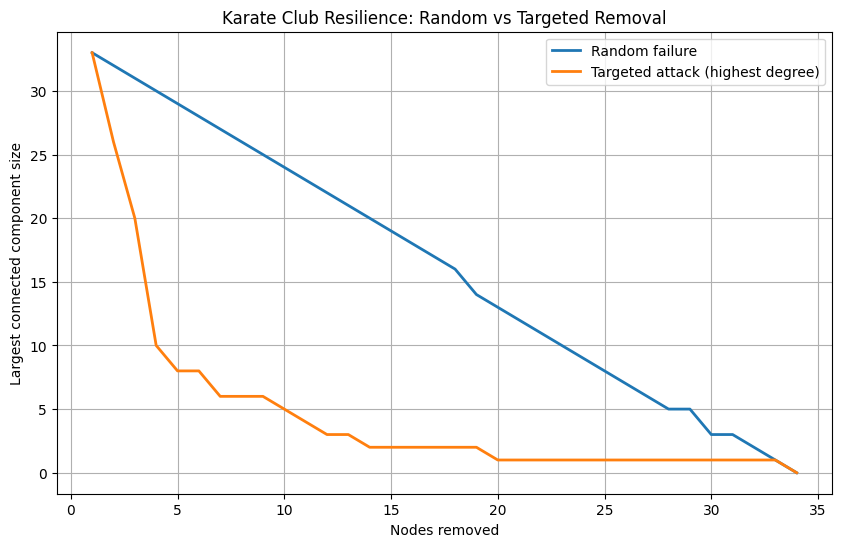

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    comparison_df["step"],
    comparison_df["random_failure"],
    label="Random failure",
    linewidth=2
)

plt.plot(
    comparison_df["step"],
    comparison_df["targeted_attack"],
    label="Targeted attack (highest degree)",
    linewidth=2
)

plt.xlabel("Nodes removed")
plt.ylabel("Largest connected component size")
plt.title("Karate Club Resilience: Random vs Targeted Removal")
plt.legend()

plt.grid(True)
plt.show()

## 6. Faction leaders and boundary members

Previous exercises identified:

- Node 0 as a major leader
- Node 33 as a major leader
- Node 32 as a boundary/high-betweenness member

We test the effect of removing them individually.


In [ ]:
important_nodes = [0, 33, 32]

results = []

for node in important_nodes:
    H = G.copy()
    H.remove_node(node)

    results.append({
        "removed_node": node,
        "largest_component_size": largest_component_size(H),
        "number_of_components": nx.number_connected_components(H)
    })

important_nodes_df = pd.DataFrame(results)

important_nodes_df

,removed_node,largest_component_size,number_of_components
0,0,27,3
1,33,33,1
2,32,33,1


## 7. Compare with random member removals

To provide context, we compare the critical removals with several ordinary members.


In [ ]:
ordinary_nodes = [5, 8, 15, 21]

ordinary_results = []

for node in ordinary_nodes:
    H = G.copy()
    H.remove_node(node)

    ordinary_results.append({
        "removed_node": node,
        "largest_component_size": largest_component_size(H),
        "number_of_components": nx.number_connected_components(H)
    })

ordinary_df = pd.DataFrame(ordinary_results)

ordinary_df

,removed_node,largest_component_size,number_of_components
0,5,33,1
1,8,33,1
2,15,33,1
3,21,33,1


## 8. Identify fragility

We compare how quickly connectivity declines in the two attack scenarios.


In [ ]:
initial_size = G.number_of_nodes()

random_half_step = comparison_df[
    comparison_df["random_failure"] <= initial_size / 2
]["step"].min()

target_half_step = comparison_df[
    comparison_df["targeted_attack"] <= initial_size / 2
]["step"].min()

fragility_df = pd.DataFrame({
    "Scenario": ["Random failure", "Targeted attack"],
    "Step when LCC <= 50% of original size": [
        random_half_step,
        target_half_step
    ]
})

fragility_df

,Scenario,Step when LCC <= 50% of original size
0,Random failure,17
1,Targeted attack,4


## 9. Visualization of important nodes

Nodes 0, 33, and 32 are highlighted because they were identified as leaders or boundary members in previous exercises.


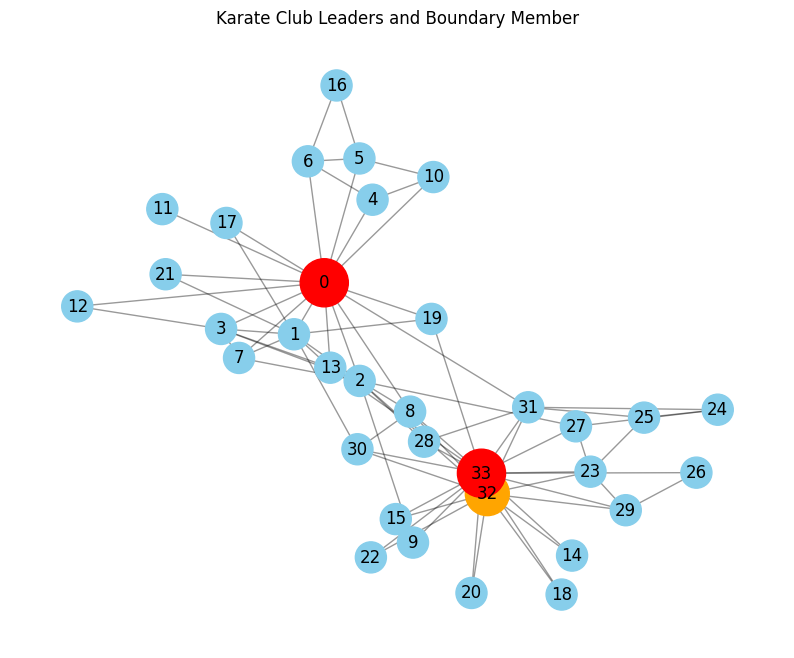

In [ ]:
pos = nx.spring_layout(G, seed=42)

node_colors = []
node_sizes = []

for node in G.nodes():
    if node in [0, 33]:
        node_colors.append("red")
        node_sizes.append(1200)
    elif node == 32:
        node_colors.append("orange")
        node_sizes.append(1000)
    else:
        node_colors.append("skyblue")
        node_sizes.append(500)

plt.figure(figsize=(10,8))

nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)
nx.draw_networkx_labels(G, pos)

plt.title("Karate Club Leaders and Boundary Member")
plt.axis("off")
plt.show()

## 10. Proposed resilience improvement

A realistic way to improve resilience would be to encourage additional connections between members from different local circles or factions.

More cross-group ties would reduce dependence on a few leaders and boundary members. If one important member leaves the club, communication and social cohesion would be less likely to fragment.
